In [5]:
#   Libraries

#   import tensorflow as tf

# import detectron2

import numpy
import cv2 as cv
import albumentations as A
import torch
import sklearn
import pycocotools
import matplotlib
import pandas as pd
from pycocotools.coco import COCO
import os
import plotly.express as px
import PIL
import torchvision
import ultralytics
import timm
import lightning
import fiftyone
import labelme
import supervision as sv
import json
import yaml
import seaborn as sns
import plotly.graph_objects as go
import tqdm
import rich
import imgaug
import kornia
import wandb
import tensorboard
import mlflow
import hydra
import omegaconf
import json, os, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from pycocotools.coco import COCO
from tqdm import tqdm
import cv2





matplotlib.use("Agg")          # headless – safe for any env


AttributeError: `np.sctypes` was removed in the NumPy 2.0 release. Access dtypes explicitly instead.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = Path(__file__).parent if "__file__" in dir() else Path(".")
ANNO_FILE   = ROOT / "data/coco_dataset/train/annotations.json"
IMG_DIR     = ROOT / "data/coco_dataset/train/images"
PROD_DIR    = ROOT / "data/product_images"
PROMPT_DIR  = ROOT / "prompt_data"
PLOT_DIR    = PROMPT_DIR / "plots"

NameError: name 'Path' is not defined

In [9]:
"""
NorgesGruppen Object Detection — Exploratory Data Analysis
Saves all key stats + metadata to prompt_data/ for future AI prompts.
Run from the priv_proj/ root.
"""

PROMPT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="darkgrid", palette="muted")
COLORS = sns.color_palette("muted", 10)

print("=" * 60)
print("NorgesGruppen EDA — loading annotations …")
print("=" * 60)

# ── Load raw JSON + COCO API ───────────────────────────────────────────────────
with open(ANNO_FILE) as f:
    raw = json.load(f)

coco = COCO(str(ANNO_FILE))

images_raw  = raw["images"]
annots_raw  = raw["annotations"]
cats_raw    = raw["categories"]

# ── Build DataFrames ───────────────────────────────────────────────────────────
df_img  = pd.DataFrame(images_raw)
df_ann  = pd.DataFrame(annots_raw)
df_cat  = pd.DataFrame(cats_raw).rename(columns={"id": "category_id"})

# Explode bbox → separate columns
df_ann[["bx", "by", "bw", "bh"]] = pd.DataFrame(df_ann["bbox"].tolist(),
                                                   index=df_ann.index)
df_ann["b_area"]   = df_ann["bw"] * df_ann["bh"]
df_ann["b_aspect"] = df_ann["bw"] / df_ann["bh"].replace(0, np.nan)

# Merge image dims into annotations
df_ann = df_ann.merge(df_img[["id", "width", "height"]]
                       .rename(columns={"id": "image_id",
                                        "width": "img_w",
                                        "height": "img_h"}),
                      on="image_id", how="left")

df_ann["rel_area"] = df_ann["b_area"] / (df_ann["img_w"] * df_ann["img_h"])
df_ann["rel_w"]    = df_ann["bw"] / df_ann["img_w"]
df_ann["rel_h"]    = df_ann["bh"] / df_ann["img_h"]

# Merge category name
df_ann = df_ann.merge(df_cat[["category_id", "name"]], on="category_id", how="left")

# Infer store section from image filename (e.g. "Egg_img_00003.jpg" or just index)
# Images may be named plainly; derive section from annotation or folder if present
# Fall back: try to find section keywords in the filename
SECTIONS = ["Egg", "Frokost", "Knekkebrod", "Varmedrikker"]

def infer_section(fname: str) -> str:
    for s in SECTIONS:
        if s.lower() in fname.lower():
            return s
    return "Unknown"

df_img["section"] = df_img["file_name"].apply(infer_section)
df_ann = df_ann.merge(df_img[["id", "section", "file_name"]]
                       .rename(columns={"id": "image_id", "file_name": "img_fname"}),
                      on="image_id", how="left")

# ── 1. TOP-LEVEL COUNTS ────────────────────────────────────────────────────────
n_images     = len(df_img)
n_annots     = len(df_ann)
n_cats       = len(df_cat)
n_products   = df_ann["product_code"].nunique()
n_corrected  = df_ann["corrected"].sum() if "corrected" in df_ann else "N/A"
anns_per_img = df_ann.groupby("image_id").size()
cats_per_img = df_ann.groupby("image_id")["category_id"].nunique()

print(f"\n{'─'*40}")
print(f"  Images              : {n_images}")
print(f"  Annotations         : {n_annots}")
print(f"  Categories          : {n_cats}")
print(f"  Unique product codes: {n_products}")
print(f"  Corrected annots    : {n_corrected}")
print(f"  Avg annots/image    : {anns_per_img.mean():.1f}")
print(f"  Min annots/image    : {anns_per_img.min()}")
print(f"  Max annots/image    : {anns_per_img.max()}")
print(f"  Avg categories/img  : {cats_per_img.mean():.1f}")
print(f"{'─'*40}\n")

# ── 2. ANNOTATIONS PER IMAGE distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Annotations per Image", fontsize=14, fontweight="bold")

axes[0].hist(anns_per_img.values, bins=30, color=COLORS[0], edgecolor="white")
axes[0].set_xlabel("Annotations per image"); axes[0].set_ylabel("Image count")
axes[0].set_title("Distribution")

axes[1].boxplot(anns_per_img.values, vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLORS[1], alpha=0.7))
axes[1].set_ylabel("Annotations"); axes[1].set_title("Box plot")
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(PLOT_DIR / "01_annots_per_image.png", dpi=150)
plt.close()
print("✓ Plot 01 — annotations per image")

# ── 3. CATEGORY FREQUENCY (top 40 + long-tail) ────────────────────────────────
cat_counts = df_ann["category_id"].value_counts()
cat_counts_named = df_ann.groupby("name").size().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle("Category Frequency", fontsize=14, fontweight="bold")

top40 = cat_counts_named.head(40)
axes[0].barh(top40.index[::-1], top40.values[::-1], color=COLORS[2])
axes[0].set_xlabel("Annotation count"); axes[0].set_title("Top 40 categories")
axes[0].tick_params(axis="y", labelsize=7)

# Long-tail sorted
axes[1].plot(range(len(cat_counts_named)), cat_counts_named.values,
             color=COLORS[3], linewidth=1.5)
axes[1].fill_between(range(len(cat_counts_named)), cat_counts_named.values,
                     alpha=0.25, color=COLORS[3])
axes[1].set_xlabel("Category rank"); axes[1].set_ylabel("Annotation count")
axes[1].set_title("Long-tail distribution (all categories)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_category_frequency.png", dpi=150)
plt.close()
print("✓ Plot 02 — category frequency")

# ── 4. BOUNDING BOX STATISTICS ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Bounding Box Statistics", fontsize=14, fontweight="bold")

pairs = [
    (df_ann["bw"],       "Box width (px)",            axes[0, 0], COLORS[0]),
    (df_ann["bh"],       "Box height (px)",           axes[0, 1], COLORS[1]),
    (df_ann["b_area"],   "Box area (px²)",            axes[0, 2], COLORS[2]),
    (df_ann["rel_w"],    "Relative width (% image)",  axes[1, 0], COLORS[3]),
    (df_ann["rel_h"],    "Relative height (% image)", axes[1, 1], COLORS[4]),
    (df_ann["b_aspect"], "Aspect ratio (w/h)",        axes[1, 2], COLORS[5]),
]
for series, label, ax, col in pairs:
    series = series.dropna()
    ax.hist(series, bins=50, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(series.median(), color="red", linestyle="--", linewidth=1.2,
               label=f"median={series.median():.2f}")
    ax.set_xlabel(label); ax.set_ylabel("Count"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_bbox_statistics.png", dpi=150)
plt.close()
print("✓ Plot 03 — bbox statistics")

# ── 5. BBOX CENTER HEATMAP ────────────────────────────────────────────────────
cx_rel = (df_ann["bx"] + df_ann["bw"] / 2) / df_ann["img_w"]
cy_rel = (df_ann["by"] + df_ann["bh"] / 2) / df_ann["img_h"]

fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(cx_rel.clip(0, 1), cy_rel.clip(0, 1),
              bins=40, cmap="hot", density=True)
plt.colorbar(h[3], ax=ax, label="Density")
ax.set_xlabel("Relative X (left → right)")
ax.set_ylabel("Relative Y (top → bottom)")
ax.set_title("Bounding Box Centre Heatmap (relative coords)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_bbox_center_heatmap.png", dpi=150)
plt.close()
print("✓ Plot 04 — bbox centre heatmap")

# ── 6. IMAGE SIZE DISTRIBUTION ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Image Dimensions", fontsize=14, fontweight="bold")

axes[0].scatter(df_img["width"], df_img["height"], alpha=0.5, color=COLORS[0], s=20)
axes[0].set_xlabel("Width (px)"); axes[0].set_ylabel("Height (px)")
axes[0].set_title("W vs H")

axes[1].hist(df_img["width"],  bins=20, color=COLORS[1], edgecolor="white")
axes[1].set_xlabel("Width (px)"); axes[1].set_title("Width distribution")

axes[2].hist(df_img["height"], bins=20, color=COLORS[2], edgecolor="white")
axes[2].set_xlabel("Height (px)"); axes[2].set_title("Height distribution")

plt.tight_layout()
plt.savefig(PLOT_DIR / "05_image_dimensions.png", dpi=150)
plt.close()
print("✓ Plot 05 — image dimensions")

# ── 7. STORE SECTION ANALYSIS ─────────────────────────────────────────────────
section_img_counts  = df_img["section"].value_counts()
section_ann_counts  = df_ann["section"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Store Sections", fontsize=14, fontweight="bold")

axes[0].bar(section_img_counts.index, section_img_counts.values, color=COLORS[:len(section_img_counts)])
axes[0].set_title("Images per section"); axes[0].set_ylabel("Count")

axes[1].bar(section_ann_counts.index, section_ann_counts.values, color=COLORS[:len(section_ann_counts)])
axes[1].set_title("Annotations per section"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(PLOT_DIR / "06_store_sections.png", dpi=150)
plt.close()
print("✓ Plot 06 — store sections")

# ── 8. CORRECTED vs UNCORRECTED ───────────────────────────────────────────────
if "corrected" in df_ann.columns:
    corr_counts = df_ann["corrected"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.pie(corr_counts.values,
           labels=[f"corrected={k}" for k in corr_counts.index],
           autopct="%1.1f%%", colors=COLORS[:2])
    ax.set_title("Annotation Correction Status", fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "07_corrected_vs_uncorrected.png", dpi=150)
    plt.close()
    print("✓ Plot 07 — corrected status")

# ── 9. CATEGORIES WITH NO PRODUCT IMAGE ──────────────────────────────────────
prod_codes_available = set()
if PROD_DIR.exists():
    prod_codes_available = {p.name for p in PROD_DIR.iterdir() if p.is_dir()}

ann_codes = set(df_ann["product_code"].dropna().astype(str).unique())
codes_missing_img  = ann_codes - prod_codes_available
codes_extra_img    = prod_codes_available - ann_codes

print(f"\nProduct image coverage:")
print(f"  Unique product codes in annotations : {len(ann_codes)}")
print(f"  Product image folders available     : {len(prod_codes_available)}")
print(f"  Codes in annots WITH no image folder: {len(codes_missing_img)}")
print(f"  Image folders with no annotation    : {len(codes_extra_img)}")

# ── 10. SMALL / MEDIUM / LARGE bbox breakdown (COCO thresholds) ───────────────
# COCO: small <32²=1024, medium 32²–96²=9216, large >9216
df_ann["size_class"] = pd.cut(
    df_ann["b_area"],
    bins=[0, 1024, 9216, np.inf],
    labels=["small (<32²)", "medium (32²–96²)", "large (>96²)"]
)
size_dist = df_ann["size_class"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(size_dist.index, size_dist.values, color=COLORS[:3])
ax.set_title("COCO Size Classes (area thresholds)", fontweight="bold")
ax.set_ylabel("Annotation count")
for i, v in enumerate(size_dist.values):
    ax.text(i, v + 30, f"{v:,}\n({v/len(df_ann)*100:.1f}%)",
            ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / "08_size_classes.png", dpi=150)
plt.close()
print("✓ Plot 08 — COCO size classes")

# ── 11. ANNOTATIONS PER CATEGORY (cumulative / coverage) ─────────────────────
cat_ann_counts = df_ann.groupby("category_id").size().sort_values()
cumulative     = np.cumsum(cat_ann_counts.values[::-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(cumulative)), cumulative / cumulative[0] * 100,
        color=COLORS[4], linewidth=2)
ax.axhline(50, linestyle="--", color="gray", linewidth=0.8, label="50% of annotations")
ax.axhline(80, linestyle="--", color="orange", linewidth=0.8, label="80% of annotations")
ax.set_xlabel("Top-N categories"); ax.set_ylabel("% of total annotations covered")
ax.set_title("Cumulative Annotation Coverage by Category (Pareto)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_pareto_coverage.png", dpi=150)
plt.close()
print("✓ Plot 09 — Pareto coverage")

# ── 12. PRODUCT IMAGE VIEW AVAILABILITY ──────────────────────────────────────
VIEWS = ["main", "front", "back", "left", "right", "top", "bottom"]
view_counts = {v: 0 for v in VIEWS}
if PROD_DIR.exists():
    for prod_folder in PROD_DIR.iterdir():
        if prod_folder.is_dir():
            for v in VIEWS:
                if (prod_folder / f"{v}.jpg").exists():
                    view_counts[v] += 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(view_counts.keys(), view_counts.values(), color=COLORS[:len(VIEWS)])
ax.set_title("Product Reference Image Availability by View", fontweight="bold")
ax.set_ylabel("Number of products with this view")
for i, (k, v) in enumerate(view_counts.items()):
    ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / "10_product_image_views.png", dpi=150)
plt.close()
print("✓ Plot 10 — product image views")

# ── 13. SAMPLE ANNOTATED IMAGE ────────────────────────────────────────────────
sample_img_id  = df_img.iloc[0]["id"]
sample_fname   = df_img.iloc[0]["file_name"]
sample_img_path = IMG_DIR / sample_fname

if sample_img_path.exists():
    img = np.array(Image.open(sample_img_path).convert("RGB"))
    sample_anns = df_ann[df_ann["image_id"] == sample_img_id]

    fig, ax = plt.subplots(figsize=(12, 9))
    ax.imshow(img)
    palette = plt.cm.get_cmap("tab20", n_cats)
    for _, row in sample_anns.iterrows():
        x, y, w, h = row["bx"], row["by"], row["bw"], row["bh"]
        color = palette(int(row["category_id"]) % 20)
        rect  = patches.Rectangle((x, y), w, h, linewidth=1.5,
                                   edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 2, str(row["category_id"]),
                fontsize=5, color=color, backgroundcolor="black")
    ax.set_title(f"Sample annotated image — {sample_fname} ({len(sample_anns)} objects)",
                 fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "11_sample_annotated_image.png", dpi=150)
    plt.close()
    print("✓ Plot 11 — sample annotated image")

# ── 14. BBOX ASPECT RATIO vs AREA SCATTER ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df_ann["b_aspect"].clip(0, 5),
                np.log1p(df_ann["b_area"]),
                alpha=0.15, s=4, c=df_ann["category_id"] % 256,
                cmap="tab20", linewidths=0)
ax.set_xlabel("Aspect ratio (w/h, clipped at 5)")
ax.set_ylabel("log(1 + area)")
ax.set_title("Aspect Ratio vs. Area per Annotation", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "12_aspect_vs_area_scatter.png", dpi=150)
plt.close()
print("✓ Plot 12 — aspect ratio vs area")

# ── SAVE STATS JSON for future prompts ───────────────────────────────────────
stats = {
    "n_images":                   n_images,
    "n_annotations":              n_annots,
    "n_categories":               n_cats,
    "n_unique_product_codes":     int(n_products),
    "n_corrected_annotations":    int(n_corrected) if isinstance(n_corrected, (int, float, np.integer)) else n_corrected,
    "avg_annotations_per_image":  round(float(anns_per_img.mean()), 2),
    "min_annotations_per_image":  int(anns_per_img.min()),
    "max_annotations_per_image":  int(anns_per_img.max()),
    "std_annotations_per_image":  round(float(anns_per_img.std()), 2),
    "avg_categories_per_image":   round(float(cats_per_img.mean()), 2),
    "image_widths":               {"mean": round(float(df_img["width"].mean()), 1),
                                   "unique_values": df_img["width"].unique().tolist()},
    "image_heights":              {"mean": round(float(df_img["height"].mean()), 1),
                                   "unique_values": df_img["height"].unique().tolist()},
    "bbox": {
        "width":  {"mean": round(float(df_ann["bw"].mean()), 1),
                   "median": round(float(df_ann["bw"].median()), 1),
                   "std": round(float(df_ann["bw"].std()), 1)},
        "height": {"mean": round(float(df_ann["bh"].mean()), 1),
                   "median": round(float(df_ann["bh"].median()), 1),
                   "std": round(float(df_ann["bh"].std()), 1)},
        "area":   {"mean": round(float(df_ann["b_area"].mean()), 1),
                   "median": round(float(df_ann["b_area"].median()), 1),
                   "std": round(float(df_ann["b_area"].std()), 1)},
        "aspect_ratio": {"mean": round(float(df_ann["b_aspect"].mean()), 3),
                         "median": round(float(df_ann["b_aspect"].median()), 3)},
        "relative_area":{"mean": round(float(df_ann["rel_area"].mean()), 5),
                         "median": round(float(df_ann["rel_area"].median()), 5)},
    },
    "size_class_counts": size_dist.to_dict(),
    "section_image_counts": section_img_counts.to_dict(),
    "section_annotation_counts": section_ann_counts.to_dict(),
    "product_image_view_counts": view_counts,
    "product_code_coverage": {
        "in_annotations": len(ann_codes),
        "image_folders_available": len(prod_codes_available),
        "missing_image_folder": len(codes_missing_img),
        "extra_image_folder_no_annotation": len(codes_extra_img),
    },
    "top_20_categories_by_annotation_count": cat_counts_named.head(20).to_dict(),
    "bottom_20_categories_by_annotation_count": cat_counts_named.tail(20).to_dict(),
    "corrected_annotation_fraction": round(
        float(df_ann["corrected"].mean()) if "corrected" in df_ann else -1, 4),
}

with open(PROMPT_DIR / "dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=2, default=str)
print("\n✓ Saved → prompt_data/dataset_stats.json")

# ── SAVE CATEGORY TABLE CSV ──────────────────────────────────────────────────
cat_summary = (
    df_ann.groupby(["category_id", "name"])
    .agg(
        annotation_count=("id", "count"),
        mean_area=("b_area", "mean"),
        median_area=("b_area", "median"),
        mean_aspect=("b_aspect", "mean"),
        n_images=("image_id", "nunique"),
    )
    .reset_index()
    .sort_values("annotation_count", ascending=False)
)
cat_summary.to_csv(PROMPT_DIR / "category_summary.csv", index=False)
print("✓ Saved → prompt_data/category_summary.csv")

# ── SAVE IMAGE TABLE CSV ─────────────────────────────────────────────────────
img_summary = df_ann.groupby("image_id").agg(
    n_annotations=("id", "count"),
    n_unique_cats=("category_id", "nunique"),
    mean_box_area=("b_area", "mean"),
    section=("section", "first"),
    file_name=("img_fname", "first"),
).reset_index()
img_summary.to_csv(PROMPT_DIR / "image_summary.csv", index=False)
print("✓ Saved → prompt_data/image_summary.csv")

# ── SAVE PRODUCT CODE COVERAGE CSV ──────────────────────────────────────────
prod_df = pd.DataFrame({
    "product_code": sorted(ann_codes),
    "has_image_folder": [c in prod_codes_available for c in sorted(ann_codes)],
})
prod_df.to_csv(PROMPT_DIR / "product_code_coverage.csv", index=False)
print("✓ Saved → prompt_data/product_code_coverage.csv")

# ── FINAL SUMMARY PRINT ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  EDA COMPLETE")
print("=" * 60)
print(f"  Plots saved to   : {PLOT_DIR}")
print(f"  Stats JSON       : {PROMPT_DIR / 'dataset_stats.json'}")
print(f"  Category CSV     : {PROMPT_DIR / 'category_summary.csv'}")
print(f"  Image CSV        : {PROMPT_DIR / 'image_summary.csv'}")
print(f"  Product coverage : {PROMPT_DIR / 'product_code_coverage.csv'}")
print("\nQuick glance at category summary:")
print(cat_summary.head(10).to_string(index=False))
print("\nSize class breakdown:")
for cls, cnt in size_dist.items():
    print(f"  {cls:30s}: {cnt:6,}  ({cnt/len(df_ann)*100:.1f}%)")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Images:      248
Categories:  356
Annotations: 22731
Product IDs: 344
Views per product (sample): {'7044416017545': ['front', 'back', 'main', 'right', 'left'], '7300400121644': ['front', 'top', 'back', 'main', 'right', 'left']}


── Dataset summary ──────────────────────────────────────────
  Images      : 248
  Categories  : 356
  Annotations : 22731  (crowd: 0)

── Bbox stats (pixels) ──────────────────────────────────────
             w        h      area
count  22731.0  22731.0   22731.0
mean     185.4    190.1   40888.0
std      113.2    106.1   43093.3
min       10.0     11.0     220.0
25%      109.0    116.0   13365.5
50%      161.0    165.0   26875.0
75%      229.0    239.0   52735.5
max     1003.0   1016.0  696082.0


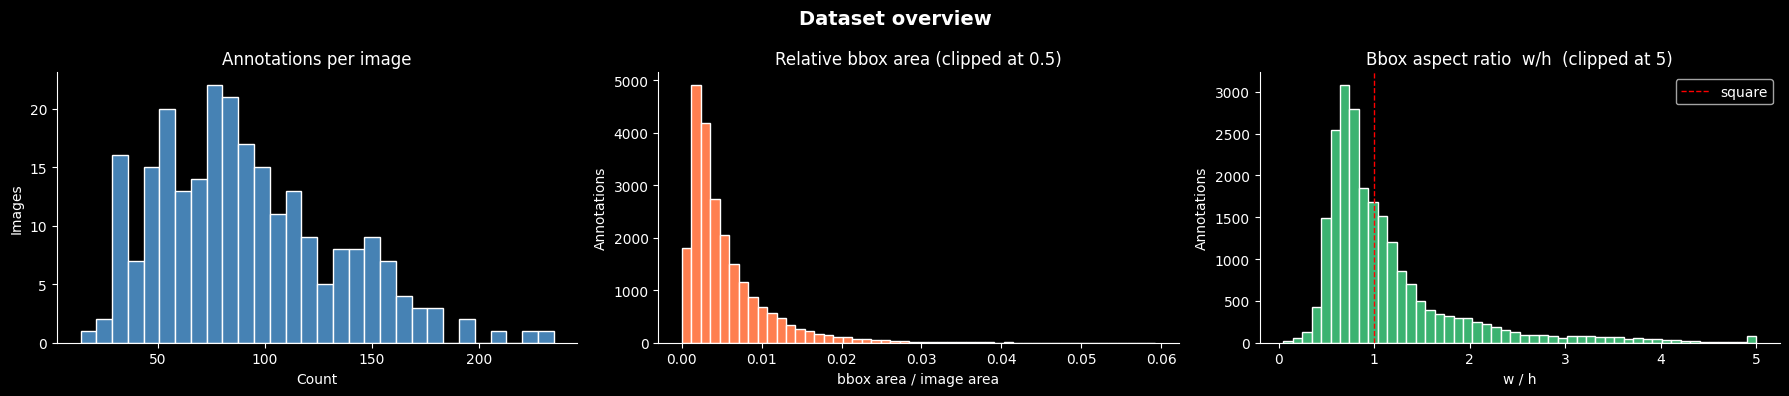

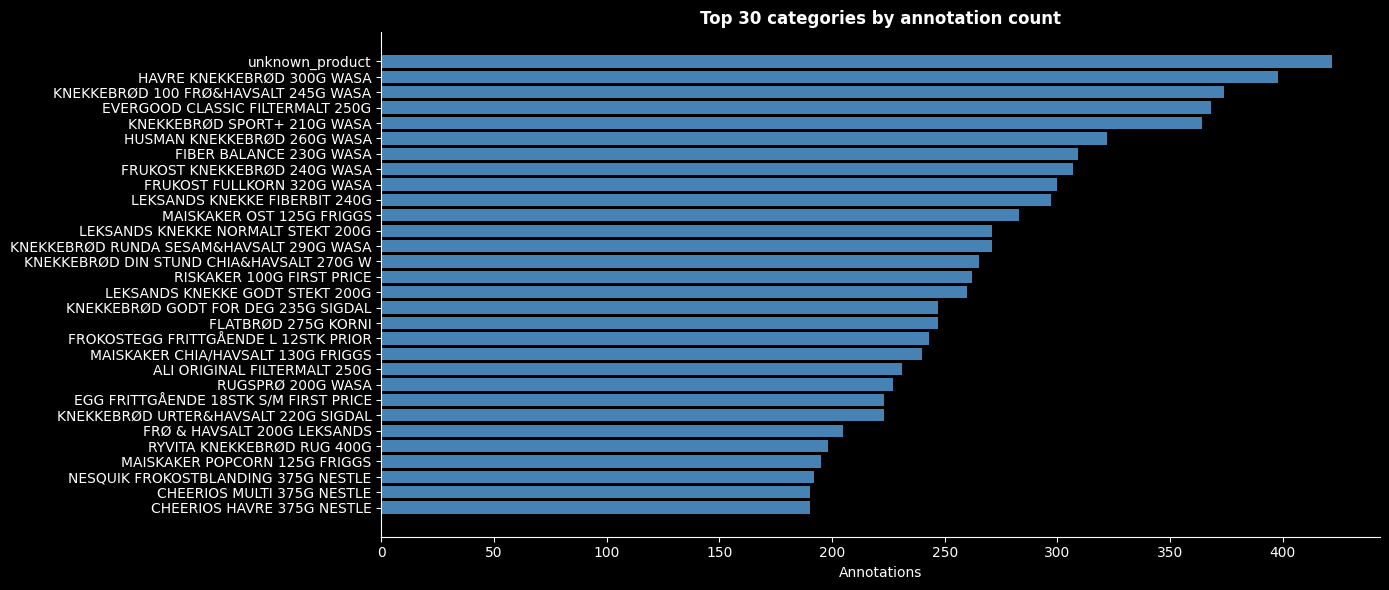

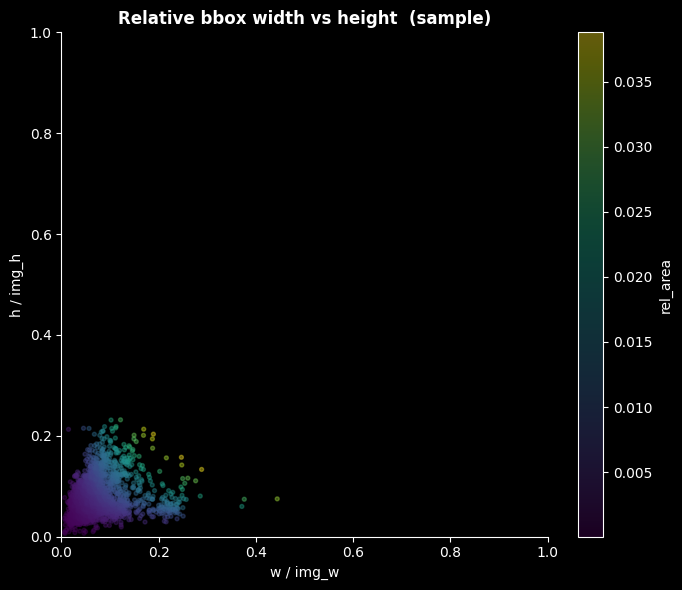

/tmp/ipykernel_16959/3470343668.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab20', df['cat_id'].nunique())


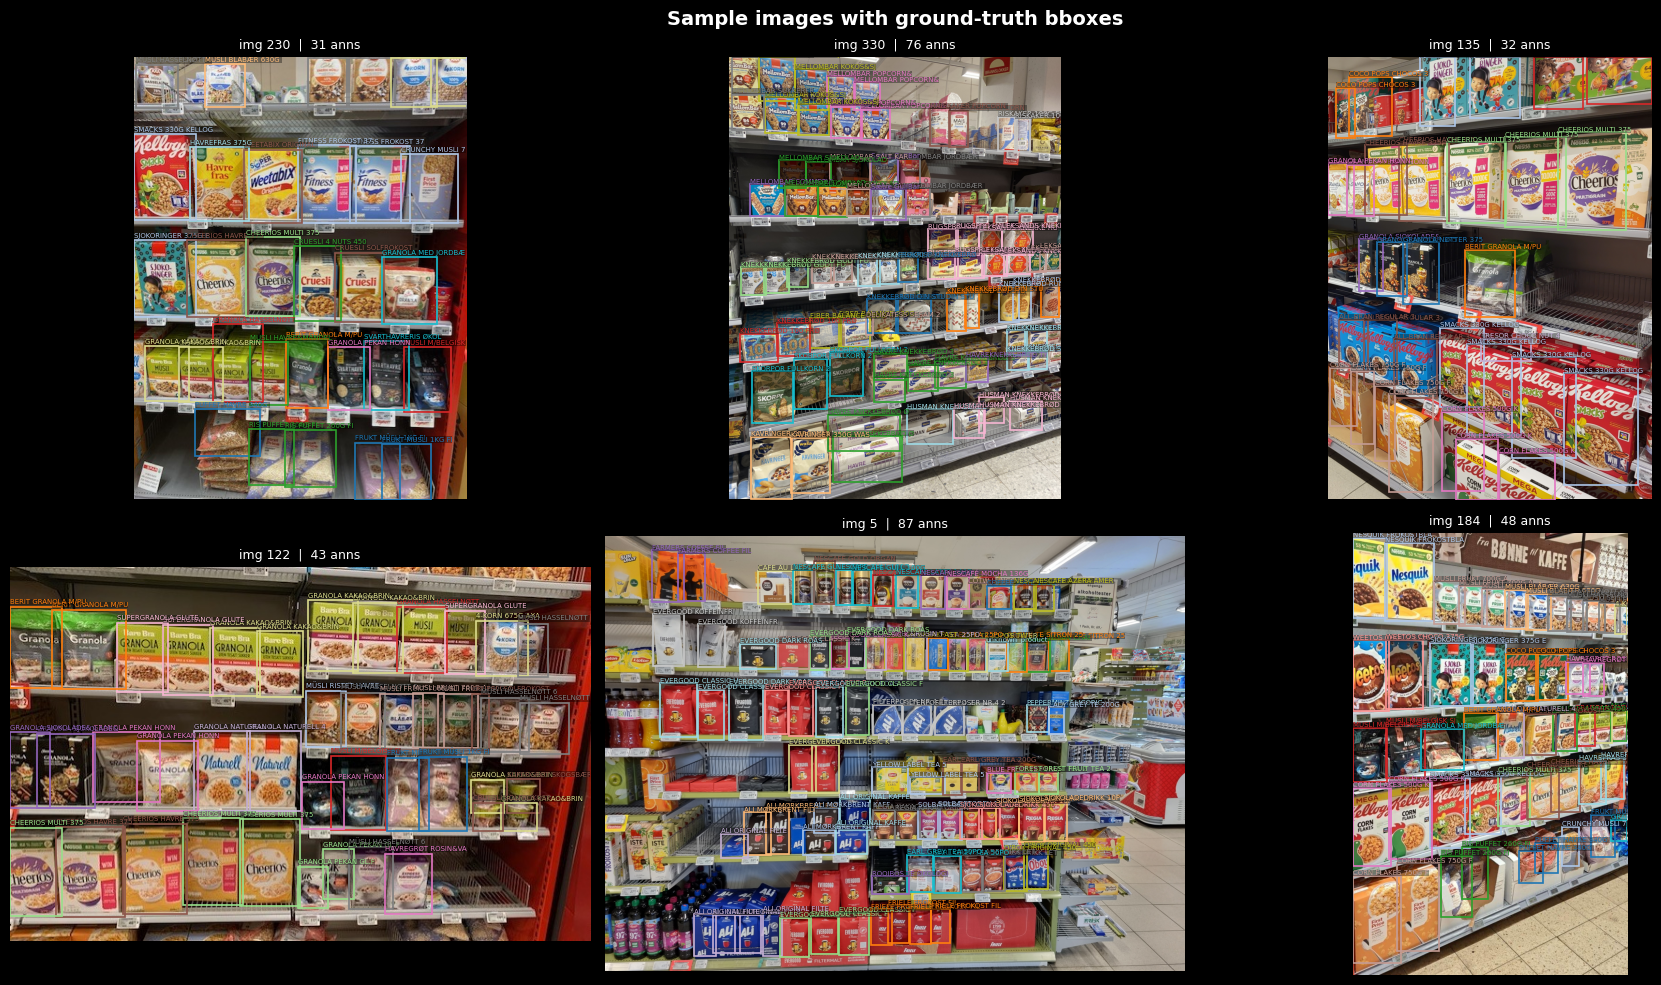


── Top 10 categories ────────────────────────────────────────
                                      n_anns  mean_area  mean_ar
cat_name                                                        
unknown_product                          422    35615.4      1.1
HAVRE KNEKKEBRØD 300G WASA               398    30397.7      1.5
KNEKKEBRØD 100 FRØ&HAVSALT 245G WASA     374    25556.0      1.1
EVERGOOD CLASSIC FILTERMALT 250G         368    23502.5      0.6
KNEKKEBRØD SPORT+ 210G WASA              364    24873.6      1.2
HUSMAN KNEKKEBRØD 260G WASA              322    29788.8      1.5
FIBER BALANCE 230G WASA                  309    25551.6      1.2
FRUKOST KNEKKEBRØD 240G WASA             307    26130.0      1.2
FRUKOST FULLKORN 320G WASA               300    32939.3      1.5
LEKSANDS KNEKKE FIBERBIT 240G            297    29481.7      1.2

── Bottom 10 categories ─────────────────────────────────────
                                     n_anns  mean_area  mean_ar
cat_name                      

In [10]:
# ── EDA ───────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2 as cv

img_dir = os.path.join(c_path, 'train/images')

# ── 1. Build a flat DataFrame of annotations ──────────────────────────────────
ann_records = []
for ann in coco.dataset['annotations']:
    img_info  = coco.imgs[ann['image_id']]
    cat_info  = coco.cats[ann['category_id']]
    x, y, w, h = ann['bbox']
    ann_records.append({
        'ann_id'    : ann['id'],
        'image_id'  : ann['image_id'],
        'file_name' : img_info['file_name'],
        'img_w'     : img_info['width'],
        'img_h'     : img_info['height'],
        'cat_id'    : ann['category_id'],
        'cat_name'  : cat_info['name'],
        'x'         : x,  'y': y,
        'w'         : w,  'h': h,
        'area'      : ann['area'],
        'iscrowd'   : ann['iscrowd'],
    })

df = pd.DataFrame(ann_records)
df['aspect_ratio']   = df['w'] / df['h'].replace(0, np.nan)
df['rel_w']          = df['w'] / df['img_w']
df['rel_h']          = df['h'] / df['img_h']
df['rel_area']       = df['area'] / (df['img_w'] * df['img_h'])

print("── Dataset summary ──────────────────────────────────────────")
print(f"  Images      : {df['image_id'].nunique()}")
print(f"  Categories  : {df['cat_id'].nunique()}")
print(f"  Annotations : {len(df)}  (crowd: {df['iscrowd'].sum()})")
print(f"\n── Bbox stats (pixels) ──────────────────────────────────────")
print(df[['w','h','area']].describe().round(1).to_string())


# ── 2. Annotations per image ──────────────────────────────────────────────────
anns_per_img = df.groupby('image_id').size()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Dataset overview', fontsize=14, fontweight='bold')

axes[0].hist(anns_per_img, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Annotations per image')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Images')
for spine in ['top','right']: axes[0].spines[spine].set_visible(False)

# ── 3. Relative bbox area distribution ────────────────────────────────────────
axes[1].hist(df['rel_area'].clip(0, 0.5), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Relative bbox area (clipped at 0.5)')
axes[1].set_xlabel('bbox area / image area')
axes[1].set_ylabel('Annotations')
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

# ── 4. Aspect-ratio distribution ──────────────────────────────────────────────
axes[2].hist(df['aspect_ratio'].clip(0, 5), bins=50, color='mediumseagreen', edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=1, label='square')
axes[2].set_title('Bbox aspect ratio  w/h  (clipped at 5)')
axes[2].set_xlabel('w / h')
axes[2].set_ylabel('Annotations')
axes[2].legend()
for spine in ['top','right']: axes[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


# ── 5. Top-30 categories by annotation count ──────────────────────────────────
top_cats = (df.groupby('cat_name').size()
              .sort_values(ascending=False)
              .head(30))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color='steelblue')
ax.set_title('Top 30 categories by annotation count', fontweight='bold')
ax.set_xlabel('Annotations')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


# ── 6. Bbox size scatter (relative w vs h, sampled) ──────────────────────────
sample = df.sample(min(3000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sample['rel_w'], sample['rel_h'],
                c=sample['rel_area'], cmap='viridis',
                alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='rel_area')
ax.set_title('Relative bbox width vs height  (sample)', fontweight='bold')
ax.set_xlabel('w / img_w')
ax.set_ylabel('h / img_h')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


# ── 7. Grid of 6 sample images with bounding boxes ───────────────────────────
COLORS = plt.cm.get_cmap('tab20', df['cat_id'].nunique())
cat_color = {cid: COLORS(i) for i, cid in enumerate(sorted(df['cat_id'].unique()))}

sample_img_ids = df['image_id'].drop_duplicates().sample(6, random_state=7).tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sample images with ground-truth bboxes', fontsize=14, fontweight='bold')

for ax, img_id in zip(axes.flat, sample_img_ids):
    img_info = coco.imgs[img_id]
    img_path = os.path.join(img_dir, img_info['file_name'])
    bgr = cv.imread(img_path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns    = coco.loadAnns(ann_ids)

    ax.imshow(rgb)
    for ann in anns:
        x, y, w, h = ann['bbox']
        cid   = ann['category_id']
        color = cat_color[cid]
        rect  = mpatches.Rectangle((x, y), w, h,
                                    linewidth=1.2, edgecolor=color,
                                    facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 3, coco.cats[cid]['name'][:18],
                fontsize=5, color=color, clip_on=True,
                bbox=dict(facecolor='black', alpha=0.35, pad=0, linewidth=0))

    ax.set_title(f"img {img_id}  |  {len(anns)} anns", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


# ── 8. Annotations-per-category statistics ────────────────────────────────────
cat_stats = (df.groupby('cat_name')
               .agg(n_anns=('ann_id','count'),
                    mean_area=('area','mean'),
                    mean_ar=('aspect_ratio','mean'))
               .sort_values('n_anns', ascending=False))

print("\n── Top 10 categories ────────────────────────────────────────")
print(cat_stats.head(10).round(1).to_string())
print("\n── Bottom 10 categories ─────────────────────────────────────")
print(cat_stats.tail(10).round(1).to_string())